<a href="https://colab.research.google.com/github/ltz22/Neural-Network-Quantum-States/blob/Call-mc_expectation_step-and-comments/3x3_ising_NQS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Basic setup, this is a 3 by 3 lattice of spin up or down particles. This is a model for magnetism called the ising model in which the total energy is determined by nearest neighbuur interactions and interactions with an external magnetic field

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import random


L = 3 #grid size 3x3 lol if you try doing 4 it runs for a bit and then crashes and 5 onwards doesnt even try to run
N = L * L
J = 1  #Coupling constant of adjacent spins
h = 0.5  #External magnetic field

#converts the array into a collumn vector [0,...8] of spins (0 or 1)
#makes the small 2d lattice wraparound so that all lattice sites have the same number of nearest neijhburs
def idx(row, col):
    return (row % L) * L + (col % L)


#Computing all eigenstates

Finding the true ground state explicitly

In [ ]:
# Make a list of all bond pairs(2 per lattice site to avoid double counting)
bonds = []
for r in range(L):
    for c in range(L):
        i = idx(r, c)
        bonds.append((i, idx(r, c + 1)))   # right neighbor
        bonds.append((i, idx(r + 1, c)))   # down neighbor


dimension = 2 ** N   #N lattice points each up or down so 2^N possible states
H = np.zeros((dimension, dimension))   #the hamiltonian is apparently represented as a matrix of 2^N by 2^N which has 2^N eigenvalues and eigenvectors (the allowed states)

for state in range(dimension): # the numbers 0 to 511 are represented by a string of 9 0s and 1s so we can simply use the range function to enumerate all possible spin configurations
    bits = [(state >> k) & 1 for k in range(N)]    # some binary magic to decompose the binary representation of "state" into a list of 0s and 1s
    spins = np.array([1 if b == 0 else -1 for b in bits])  # convention of 0 corresponding to spin up and 1 corresponding to spin down, bit 0 -> +1, bit 1 -> -1


    # diagonal part: -J * sum_<i,j> s_i s_j
    diag = sum(-J * spins[i] * spins[j] for (i, j) in bonds)
    H[state, state] += diag

    # off-diagonal part: -h * sum_i sigma^x_i (flips spin i)
    for i in range(N):
        flipped = state ^ (1 << i)
        H[state, flipped] += -h

    #the above two steps construct the hamiltonian matrix based on the ising model rules


#diagonalising gives the eigenvalues(energies) in ascending order with their corresponding eigenvectors(states)
eigvals, eigvecs = np.linalg.eigh(H)
E0 = eigvals[0]
print(f"Ground state energy: {E0:.6f}")
print(f"First 5 eigenvalues: {eigvals[:5]}")




Ground state energy: -18.281621
First 5 eigenvalues: [-18.28162062 -18.28161951 -10.47466519 -10.47166004 -10.37744076]


This code just takes the 4 lowest energy states and visualises them(completetly vibe coded)

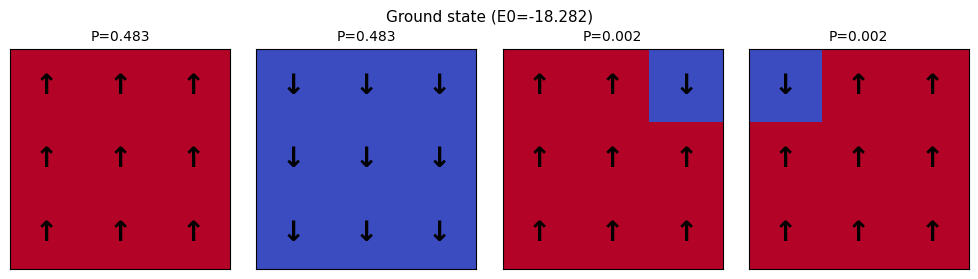

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L = 3
N = L * L

def idx(row, col):
    return (row % L) * L + (col % L)

def decode_spins(state, N=N):
    """Turn an integer state index into an (L,L) grid of +1/-1 spins."""
    bits = [(state >> k) & 1 for k in range(N)]
    spins = np.array([1 if b == 0 else -1 for b in bits])
    grid = np.zeros((L, L))
    for r in range(L):
        for c in range(L):
            grid[r, c] = spins[idx(r, c)]
    return grid

def plot_single_state(state, ax=None, title=None):
    """Visualize one basis state (an integer index) as an up/down arrow grid."""
    grid = decode_spins(state)
    if ax is None:
        fig, ax = plt.subplots(figsize=(2.5, 2.5))
    ax.imshow(grid, cmap='coolwarm', vmin=-1, vmax=1)
    for r in range(L):
        for c in range(L):
            arrow = '↑' if grid[r, c] == 1 else '↓'
            ax.text(c, r, arrow, ha='center', va='center', fontsize=20, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title or f"state={state}", fontsize=10)
    return ax

def plot_wavefunction(psi, top_k=4, title_prefix=""):
    """
    Take a full 512-entry state vector (e.g. an eigenvector column from
    np.linalg.eigh) and plot the top_k configurations with the largest
    probability weight |psi(s)|^2.
    """
    probs = np.abs(psi)**2
    top_states = np.argsort(probs)[::-1][:top_k]
    fig, axes = plt.subplots(1, top_k, figsize=(2.5*top_k, 2.8))
    if top_k == 1:
        axes = [axes]
    for ax, state in zip(axes, top_states):
        plot_single_state(state, ax=ax, title=f"P={probs[state]:.3f}")
    fig.suptitle(title_prefix, fontsize=11)
    plt.tight_layout()
    plt.show()
    return top_states, probs[top_states]

# usage on your ground-state vector from exact diagonalization:
top_states, top_probs = plot_wavefunction(
    eigvecs[:, 0], top_k=4, title_prefix=f"Ground state (E0={eigvals[0]:.3f})")

# NQS

Defining the basic network structure and initialising

In [ ]:
def periodic_conv_features(spins_grid, W, b):
    """
    spins_grid: (L,L) array of +1/-1
    W: (C, 2, 2) filter weights, one 2x2 filter per channel
    b: (C,) biases
    Returns (C, L, L) feature maps, using periodic (wrap-around) padding.
    """
    C = W.shape[0]
    padded = jnp.pad(spins_grid, ((0, 1), (0, 1)), mode='wrap')
    feats = []
    for c in range(C):
        out = (W[c, 0, 0] * padded[0:L, 0:L]     + W[c, 0, 1] * padded[0:L, 1:L+1] +
               W[c, 1, 0] * padded[1:L+1, 0:L]    + W[c, 1, 1] * padded[1:L+1, 1:L+1] + b[c])
        feats.append(out)
    return jnp.stack(feats, axis=0)

def raw_network(params, spins_grid):
    """Un-symmetrized network: conv -> log-cosh -> sum-pool -> scalar."""
    feats = periodic_conv_features(spins_grid, params['W'], params['b'])
    activated = jnp.log(jnp.cosh(feats))
    return jnp.sum(activated)

def log_psi(params, spins_grid):
    """Spin-flip symmetrized log-wavefunction."""
    raw_pos = raw_network(params, spins_grid)
    raw_neg = raw_network(params, -spins_grid)
    return jax.scipy.special.logsumexp(jnp.array([raw_pos, raw_neg]))

3
key = random.PRNGKey(0)
C = 4
#this is intresting, the program uses channels to allow caputuring more distinct patterns,
 #the idea is that there are 4 distinct 2x2 filters that are applied to each lattice point,
 # this maintains translational symtery but allows for capturing more complicated patterns

k1, k2 = random.split(key)
params = {
    'W': random.normal(k1, (C, 2, 2)) * 0.1,
    'b': random.normal(k2, (C,)) * 0.1,
}

Random monto carlo sampling and gradient descent

In [ ]:
import jax
jax.config.update("jax_enable_x64", True)  # you already tested this

import jax.numpy as jnp
from jax import random
import itertools
import numpy as np

L = 3
N = L * L
J = 1.0
h = 0.5
EXACT_E0 = -18.281621

def periodic_conv_features(spins_grid, W, b):
    C = W.shape[0]
    padded = jnp.pad(spins_grid, ((0, 1), (0, 1)), mode='wrap')
    feats = []
    for c in range(C):
        out = (W[c, 0, 0] * padded[0:L, 0:L]     + W[c, 0, 1] * padded[0:L, 1:L+1] +
               W[c, 1, 0] * padded[1:L+1, 0:L]    + W[c, 1, 1] * padded[1:L+1, 1:L+1] + b[c])
        feats.append(out)
    return jnp.stack(feats, axis=0)

def raw_network(params, spins_grid):
    feats = periodic_conv_features(spins_grid, params['W'], params['b'])
    return jnp.sum(jnp.log(jnp.cosh(feats)))

def log_psi(params, spins_grid):
    raw_pos = raw_network(params, spins_grid)
    raw_neg = raw_network(params, -spins_grid)
    return jax.scipy.special.logsumexp(jnp.array([raw_pos, raw_neg]))

def local_energy(params, spins_grid):
    e_diag = -J * jnp.sum(spins_grid * jnp.roll(spins_grid, -1, axis=1)) \
             -J * jnp.sum(spins_grid * jnp.roll(spins_grid, -1, axis=0))
    log_psi_s = log_psi(params, spins_grid)
    def flip_and_logpsi(r, c):
        flipped = spins_grid.at[r, c].multiply(-1)
        return log_psi(params, flipped)
    rs, cs = jnp.meshgrid(jnp.arange(L), jnp.arange(L), indexing='ij')
    log_psi_flips = jax.vmap(flip_and_logpsi)(rs.flatten(), cs.flatten())
    e_offdiag = -h * jnp.sum(jnp.exp(log_psi_flips - log_psi_s))
    return e_diag + e_offdiag

log_psi_jit = jax.jit(log_psi)
local_energy_jit = jax.jit(local_energy)
grad_log_psi_jit = jax.jit(jax.grad(log_psi))

#Current input is
all_grids = jnp.array([
    np.array(config).reshape(L, L)
    for config in itertools.product([-1.0, 1.0], repeat=N)
])

log_psi_vmap = jax.vmap(log_psi_jit, in_axes=(None, 0))
local_energy_vmap = jax.vmap(local_energy_jit, in_axes=(None, 0))
grad_log_psi_vmap = jax.vmap(grad_log_psi_jit, in_axes=(None, 0))

def exact_expectation_step(params):
    log_psis = log_psi_vmap(params, all_grids)
    log_probs_unnorm = 2 * log_psis
    log_probs_unnorm -= jnp.max(log_probs_unnorm)
    unnorm_prob = jnp.exp(log_probs_unnorm)
    probs = unnorm_prob / jnp.sum(unnorm_prob)

    E_locs = local_energy_vmap(params, all_grids)
    grads = grad_log_psi_vmap(params, all_grids)
    mean_E = jnp.sum(probs * E_locs)

    grad_update = {}
    for kname in params:
        g = grads[kname]
        p_bcast = probs.reshape((512,) + (1,) * (g.ndim - 1))
        mean_grad = jnp.sum(p_bcast * g, axis=0)
        E_bcast = E_locs.reshape((512,) + (1,) * (g.ndim - 1))
        mean_E_grad = jnp.sum(p_bcast * E_bcast * g, axis=0)
        grad_update[kname] = 2 * (mean_E_grad - mean_E * mean_grad)

    max_prob = jnp.max(probs)
    return mean_E, grad_update, max_prob, probs, log_probs_unnorm

key = random.PRNGKey(0)
C = 4
k1, k2 = random.split(key)
params = {
    'W': random.normal(k1, (C, 2, 2)) * 0.1,
    'b': random.normal(k2, (C,)) * 0.1,
}

lr = 0.05
n_iterations = 300
for it in range(n_iterations):
    mean_E, grad_update, max_prob, probs, log_probs_unnorm = exact_expectation_step(params)

    grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in grad_update.values()))
    W_norm = jnp.sqrt(jnp.sum(params['W']**2))

    params = {k_: params[k_] - lr * grad_update[k_] for k_ in params}

    if it % 20 == 0 or it == n_iterations - 1:
        # high-precision printing this time
        second_highest = jnp.sort(probs)[-3]  # third-largest, since two peaks are equal
        print(f"iter {it:4d}  E={mean_E:.10f}  |grad|={grad_norm:.3e}  "
              f"max_prob={max_prob:.15f}  3rd_prob={second_highest:.3e}  |W|={W_norm:.4f}")

iter    0  E=-4.0706584052  |grad|=1.598e+01  max_prob=0.004127079303791  3rd_prob=4.127e-03  |W|=0.4341
iter   20  E=-18.2791092136  |grad|=1.621e-02  max_prob=0.483267753563115  3rd_prob=1.783e-03  |W|=0.8354
iter   40  E=-18.2793476624  |grad|=1.468e-02  max_prob=0.483214019635356  3rd_prob=1.790e-03  |W|=0.8304
iter   60  E=-18.2795448914  |grad|=1.341e-02  max_prob=0.483169244596785  3rd_prob=1.797e-03  |W|=0.8260
iter   80  E=-18.2797106973  |grad|=1.234e-02  max_prob=0.483131348860515  3rd_prob=1.802e-03  |W|=0.8222
iter  100  E=-18.2798520015  |grad|=1.143e-02  max_prob=0.483098851090418  3rd_prob=1.807e-03  |W|=0.8189
iter  120  E=-18.2799738331  |grad|=1.064e-02  max_prob=0.483070667238829  3rd_prob=1.811e-03  |W|=0.8159
iter  140  E=-18.2800799342  |grad|=9.954e-03  max_prob=0.483045985601612  3rd_prob=1.815e-03  |W|=0.8132
iter  160  E=-18.2801731468  |grad|=9.349e-03  max_prob=0.483024186272894  3rd_prob=1.818e-03  |W|=0.8108
iter  180  E=-18.2802556683  |grad|=8.813e-03  

In [2]:
import jax
jax.config.update("jax_enable_x64", True)  # you already tested this

import jax.numpy as jnp
from jax import random
import itertools
import numpy as np

L = 3 #size of lattice
N = L * L
J = 1.0
h = 0.5
EXACT_E0 = -18.281621 #Expected energy

def periodic_conv_features(spins_grid, W, b):
    C = W.shape[0] # dimension of weights
    padded = jnp.pad(spins_grid, ((0, 1), (0, 1)), mode='wrap')
    feats = []
    for c in range(C):
        out = (W[c, 0, 0] * padded[0:L, 0:L]     + W[c, 0, 1] * padded[0:L, 1:L+1] +
               W[c, 1, 0] * padded[1:L+1, 0:L]    + W[c, 1, 1] * padded[1:L+1, 1:L+1] + b[c]) # apply 2 by 2 filter
        feats.append(out)
    return jnp.stack(feats, axis=0)

def raw_network(params, spins_grid):
    feats = periodic_conv_features(spins_grid, params['W'], params['b'])
    return jnp.sum(jnp.log(jnp.cosh(feats))) # activation function is log(cosh(x))

def log_psi(params, spins_grid):
    raw_pos = raw_network(params, spins_grid)
    raw_neg = raw_network(params, -spins_grid) # run it for both direction of spin
    return jax.scipy.special.logsumexp(jnp.array([raw_pos, raw_neg])) # take some sort of average

def local_energy(params, spins_grid):
    e_diag = -J * jnp.sum(spins_grid * jnp.roll(spins_grid, -1, axis=1)) \
             -J * jnp.sum(spins_grid * jnp.roll(spins_grid, -1, axis=0))
    log_psi_s = log_psi(params, spins_grid)
    def flip_and_logpsi(r, c):
        flipped = spins_grid.at[r, c].multiply(-1)
        return log_psi(params, flipped)
    rs, cs = jnp.meshgrid(jnp.arange(L), jnp.arange(L), indexing='ij')
    log_psi_flips = jax.vmap(flip_and_logpsi)(rs.flatten(), cs.flatten())
    e_offdiag = -h * jnp.sum(jnp.exp(log_psi_flips - log_psi_s))
    return e_diag + e_offdiag # no idea broski

log_psi_jit = jax.jit(log_psi)
local_energy_jit = jax.jit(local_energy)
grad_log_psi_jit = jax.jit(jax.grad(log_psi)) #Jit optimises stuff apparently

log_psi_vmap = jax.vmap(log_psi_jit, in_axes=(None, 0))
local_energy_vmap = jax.vmap(local_energy_jit, in_axes=(None, 0))
grad_log_psi_vmap = jax.vmap(grad_log_psi_jit, in_axes=(None, 0)) #vmap optimises stuff apparently

#Without random sampling
"""
def exact_expectation_step(params):
    log_psis = log_psi_vmap(params, all_grids)
    log_probs_unnorm = 2 * log_psis
    log_probs_unnorm -= jnp.max(log_probs_unnorm)
    unnorm_prob = jnp.exp(log_probs_unnorm)
    probs = unnorm_prob / jnp.sum(unnorm_prob)

    E_locs = local_energy_vmap(params, all_grids)
    grads = grad_log_psi_vmap(params, all_grids)
    mean_E = jnp.sum(probs * E_locs)

    grad_update = {}
    for kname in params:
        g = grads[kname]
        p_bcast = probs.reshape((512,) + (1,) * (g.ndim - 1))
        mean_grad = jnp.sum(p_bcast * g, axis=0)
        E_bcast = E_locs.reshape((512,) + (1,) * (g.ndim - 1))
        mean_E_grad = jnp.sum(p_bcast * E_bcast * g, axis=0)
        grad_update[kname] = 2 * (mean_E_grad - mean_E * mean_grad)

    max_prob = jnp.max(probs)
    return mean_E, grad_update, max_prob, probs, log_probs_unnorm
"""

def metropolis_chain(params, key, init_spins, n_steps):
    log_psi_init = log_psi_jit(params, init_spins) #compute an initial log_psi with randomised initial spins

    #Call this step function inside the chain function n_steps times
    def step(carry, key):
        spins, lp = carry #carry is composed of (spins_config, log_psi) after each step
        k_site, k_accept = random.split(key) #create random keys on what to flip and to determine whether to accept
        site = random.randint(k_site, (), 0, N) #using k_site to generate a random site within the dimension L
        r, c = site // L, site % L
        proposal = spins.at[r, c].multiply(-1) #flip the site
        lp_prop = log_psi_jit(params, proposal) #Compute proposed log probability
        log_ratio = 2 * (lp_prop - lp) #Compute a ratio of proposed log prob and original log prob (2 * for squared)
        accept = jnp.log(random.uniform(k_accept)) < log_ratio #if the log of k_accept is less than ratio, accept (so that we have random acceptance)
        new_spins = jnp.where(accept, proposal, spins) #If accept, go with the proposed spins one, if not, stick with original spins
        new_lp = jnp.where(accept, lp_prop, lp) #Same thing as above
        return (new_spins, new_lp), new_spins #Return spins and log psi as carry (which goes to the next iteration), new_spins goes into a record of trajectory

    keys = random.split(key, n_steps) #Ensure every step has a different key
    (_, _), traj = jax.lax.scan(step, (init_spins, log_psi_init), keys) #Optimised for-loop to call step iteratively, append state after each iteration in traj
    return traj  # (n_steps, L, L)

#create multiple chains of sample from metropolis_chain
#burn_in ignores initial steps to elimitate initialisation bias, n_keep is how many to keep, thin is spacing between kept samples
#This reduces correlation between samples
def sample_states(params, key, n_chains, burn_in, n_keep, thin):
    n_steps = burn_in + n_keep * thin #Compute how many steps to take
    k_init, k_chains = random.split(key)
    init_keys = random.split(k_init, n_chains) #Each chain gets a unique random initial key
    step_keys = random.split(k_chains, n_chains) #Each step gets a key as well

    init_spins = jax.vmap(lambda k: random.choice(k, jnp.array([-1.0, 1.0]), (L, L)))(init_keys) #For every chain, returns a randomised grid of spin configuration
    trajs = jax.vmap(metropolis_chain, in_axes=(None, 0, 0, None))(params, step_keys, init_spins, n_steps) #Run all metropolis_chain
    #Keep params and n_steps the same, change step_keys and give each chain a different starting lattice everytime
    # trajs: (n_chains, n_steps, L, L) -> discard burn-in, thin, flatten chains
    kept = trajs[:, burn_in::thin, :, :] #Only for the step attribute(second dimension), start and burn_in and thin
    return kept.reshape(-1, L, L) #Concatenate chains into many samples of spin lattices

#set chaining parameters
def mc_expectation_step(params, key, n_chains=64, burn_in=200, n_keep=100, thin=5):
    samples = sample_states(params, key, n_chains, burn_in, n_keep, thin)
    n_total = samples.shape[0] #obtain all the samples and total number of samples

    E_locs = local_energy_vmap(params, samples) # compute local energy for every sample, results in a n_chains * n_keep rows vector
    grads = grad_log_psi_vmap(params, samples) #Calculate gradient for every sample (how does wavefunction change when changing the parameters)
    mean_E = jnp.mean(E_locs) #average all sample energies to produce final estimate

    grad_update = {} #empty dictionary to store params update
    #Loop over weights first, then biases
    for kname in params:
        g = grads[kname] #get gradient for this parameter
        mean_grad = jnp.mean(g, axis=0) #Take the average gradient over all samples
        E_bcast = E_locs.reshape((n_total,) + (1,) * (g.ndim - 1)) #Do some dimension reshaping tricks to make multiplication work
        mean_E_grad = jnp.mean(E_bcast * g, axis=0)
        grad_update[kname] = 2 * (mean_E_grad - mean_E * mean_grad) #Compute final gradient update by some random formula

    return mean_E, grad_update, samples

#generate pseudo-random key
key = random.PRNGKey(0)
#number of channels
C = 4
k1, k2 = random.split(key)
params = {
    'W': random.normal(k1, (C, 2, 2)) * 0.1,
    'b': random.normal(k2, (C,)) * 0.1,
}

#Learning rate, for now constant
lr = 0.05
n_iterations = 100
for it in range(n_iterations):
    mean_E, grad_update, samples = mc_expectation_step(params, k2)

    grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in grad_update.values()))
    W_norm = jnp.sqrt(jnp.sum(params['W']**2))

    #gradient descent
    params = {k: params[k] - lr * grad_update[k] for k in params}

    if it % 20 == 0 or it == n_iterations - 1:
        print(f"iter {it:4d} E={mean_E:.10f} |grad|={grad_norm:.3e} |W|={W_norm:.4f}")

iter    0 E=-4.1534940577 |grad|=1.672e+01 |W|=0.4341
iter   20 E=-18.2765586961 |grad|=2.379e-02 |W|=0.8477


KeyboardInterrupt: 